# Framingham Heart Study
## Analisis Exploratorio e Inferencial

**Curso**: MCDIA501 - Estadistica Computacional para la Toma de Decisiones  
**Evaluacion**: Sumativa 1 | Fase 1  


| Campo | Detalle |
|---|---|
| **Integrantes** | Francisco Santelices - Renato Villazon - Fabian Castillo |
| **Docente** | PhD. Jean Paul Maidana Gonzalez |
| **Dataset** | Framingham Heart Study (n = 4,238 registros, 16 variables) |
| **Repositorio** | https://github.com/Bass-i/framingham-heart-risk-analysis |

---

### Estructura del notebook

| # | Seccion 
|---|---|
| 1 | Configuracion e imports 
| 2 | Carga y preparacion de datos 
| 3 | Estadistica descriptiva 
| 4 | Visualizaciones 
| 5 | Estimacion puntual e IC 
| 6 | Pruebas de hipotesis (3 pruebas) 
| 7 | Correlaciones 
| 8 | Interpretacion y sintesis 



---
## 1. Configuracion e imports

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency
from statsmodels.stats.proportion import proportion_confint
from pathlib import Path

# Semilla fija para reproducibilidad
np.random.seed(42)

# Configuracion visual
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

# Nivel de significancia global
ALPHA = 0.05

print('Librerias cargadas correctamente.')
print(f'  Python      {sys.version.split()[0]}')
print(f'  pandas      {pd.__version__}')
print(f'  numpy       {np.__version__}')
print(f'  scipy       {scipy.__version__}')
print(f'\nSemilla fija: np.random.seed(42)')
print(f'Nivel de significancia global: alpha = {ALPHA}')


Librerias cargadas correctamente.
  Python      3.12.3
  pandas      3.0.2
  numpy       2.4.4
  scipy       1.17.1

Semilla fija: np.random.seed(42)
Nivel de significancia global: alpha = 0.05


---
## 2. Carga y preparacion de datos

Se carga el dataset, se verifica su estructura y se documenta el tratamiento de valores faltantes antes de iniciar el analisis.


In [2]:
# Carga del dataset usando Path para compatibilidad entre sistemas operativos
DATA_PATH = Path('../data/framingham.csv')

df_raw = pd.read_csv(DATA_PATH)

print(f'Dataset cargado: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')
df_raw.head()

Dataset cargado: 4,240 filas x 16 columnas


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
# Informacion general: tipos de datos y valores nulos por variable
print('Informacion general del dataset:')
df_raw.info()

Informacion general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 

In [4]:
# Reporte de valores faltantes
nulos = df_raw.isnull().sum()
pct   = (nulos / len(df_raw) * 100).round(2)

faltantes = pd.DataFrame({
    'Faltantes': nulos,
    'Porcentaje (%)': pct
}).sort_values('Porcentaje (%)', ascending=False)

print('Variables con valores faltantes:')
display(faltantes[faltantes['Faltantes'] > 0])

print(f'\nRegistros originales           : {len(df_raw):,}')
print(f'Registros tras dropna()        : {df_raw.dropna().shape[0]:,}')
print(f'Registros eliminados           : {len(df_raw) - df_raw.dropna().shape[0]}')
print()
print('Decision metodologica:')
print('  Se aplica Listwise Deletion (dropna()) para garantizar consistencia')
print('  del conjunto de datos. La perdida de registros (13.7%) es aceptable')
print('  dado el tamano muestral resultante (n = 3.658).')

Variables con valores faltantes:


,Faltantes,Porcentaje (%)
glucose,388,9.15
education,105,2.48
BPMeds,53,1.25
totChol,50,1.18
cigsPerDay,29,0.68
BMI,19,0.45
heartRate,1,0.02



Registros originales           : 4,240
Registros tras dropna()        : 3,658
Registros eliminados           : 582

Decision metodologica:
  Se aplica Listwise Deletion (dropna()) para garantizar consistencia
  del conjunto de datos. La perdida de registros (13.7%) es aceptable
  dado el tamano muestral resultante (n = 3.658).


In [5]:
# Aplicar limpieza y verificar resultado
df = df_raw.dropna().copy()
df = df.reset_index(drop=True)

# Agregar columnas auxiliares de etiquetas para visualizaciones
df['CHD_Label']    = df['TenYearCHD'].map({0: 'No desarrollo enfermedad',
                                            1: 'Desarrollo enfermedad'})
df['Smoker_Label'] = df['currentSmoker'].map({0: 'No fumador', 1: 'Fumador'})
df['Sex_Label']    = df['male'].map({0: 'Mujer', 1: 'Hombre'})

print(f'Dataset listo para analisis: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataset listo para analisis: 3,658 filas x 19 columnas


---
## 3. Estadistica descriptiva

Se aplican medidas de tendencia central y dispersion diferenciadas por tipo de variable.

In [6]:
# Variables segun tipo estadistico
VARS_NUM = ['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
VARS_CAT = ['male', 'currentSmoker', 'BPMeds', 'diabetes', 'TenYearCHD']

# Tabla de clasificacion de variables
clasificacion = pd.DataFrame({
    'Variable': [
        'male','age','education','currentSmoker','cigsPerDay',
        'BPMeds','prevalentStroke','prevalentHyp','diabetes',
        'totChol','sysBP','diaBP','BMI','heartRate','glucose','TenYearCHD'
    ],
    'Tipo': [
        'Cualitativa','Cuantitativa','Cualitativa','Cualitativa','Cuantitativa',
        'Cualitativa','Cualitativa','Cualitativa','Cualitativa',
        'Cuantitativa','Cuantitativa','Cuantitativa','Cuantitativa',
        'Cuantitativa','Cuantitativa','Cualitativa'
    ],
    'Subtipo': [
        'Nominal binaria','Discreta','Ordinal','Nominal binaria','Discreta',
        'Nominal binaria','Nominal binaria','Nominal binaria','Nominal binaria',
        'Continua','Continua','Continua','Continua','Continua','Continua',
        'Nominal binaria'
    ],
    'Rol': [
        'Demografica','Demografica','Demografica','Conductual','Conductual',
        'Clinica','Clinica','Clinica','Clinica',
        'Clinica','Clinica','Clinica','Clinica','Clinica','Clinica',
        'Variable objetivo'
    ]
})

print('Clasificacion de variables del dataset:')
display(clasificacion.set_index('Variable'))


Clasificacion de variables del dataset:


,Tipo,Subtipo,Rol
Variable,,,
male,Cualitativa,Nominal binaria,Demografica
age,Cuantitativa,Discreta,Demografica
education,Cualitativa,Ordinal,Demografica
currentSmoker,Cualitativa,Nominal binaria,Conductual
cigsPerDay,Cuantitativa,Discreta,Conductual
BPMeds,Cualitativa,Nominal binaria,Clinica
prevalentStroke,Cualitativa,Nominal binaria,Clinica
prevalentHyp,Cualitativa,Nominal binaria,Clinica
diabetes,Cualitativa,Nominal binaria,Clinica


In [7]:
# Estadistica descriptiva: variables numericas
# Media, mediana, desviacion estandar, minimo y maximo
resumen = pd.DataFrame({
    'Media':           df[VARS_NUM].mean().round(2),
    'Mediana':         df[VARS_NUM].median().round(2),
    'Desv. Estandar':  df[VARS_NUM].std(ddof=1).round(2),
    'Minimo':          df[VARS_NUM].min().round(2),
    'Maximo':          df[VARS_NUM].max().round(2),
})

print('Estadistica descriptiva - variables numericas:')
display(resumen)

print()
print('Interpretacion clinica:')
print(f'  Colesterol promedio : {df["totChol"].mean():.2f} mg/dL'
      f' -> supera limite deseable de 200 mg/dL (NCEP, 2002)')
print(f'  IMC promedio        : {df["BMI"].mean():.2f} kg/m2'
      f' -> categoria sobrepeso (OMS, 2021)')
print(f'  Presion sistolica   : {df["sysBP"].mean():.2f} mmHg'
      f' -> rango hipertension etapa 1 (AHA/ACC, 2018)')


Estadistica descriptiva - variables numericas:


,Media,Mediana,Desv. Estandar,Minimo,Maximo
age,49.55,49.00,8.56,32.00,70.0
totChol,236.85,234.00,44.10,113.00,600.0
sysBP,132.37,128.00,22.09,83.50,295.0
diaBP,82.92,82.00,11.97,48.00,142.5
BMI,25.78,25.38,4.07,15.54,56.8
heartRate,75.73,75.00,11.98,44.00,143.0
glucose,81.85,78.00,23.90,40.00,394.0



Interpretacion clinica:
  Colesterol promedio : 236.85 mg/dL -> supera limite deseable de 200 mg/dL (NCEP, 2002)
  IMC promedio        : 25.78 kg/m2 -> categoria sobrepeso (OMS, 2021)
  Presion sistolica   : 132.37 mmHg -> rango hipertension etapa 1 (AHA/ACC, 2018)


In [8]:
# Estadistica descriptiva: variables categoricas
# Frecuencias absolutas y relativas
print('Frecuencias - variables categoricas:\n')
for col in VARS_CAT:
    vc  = df[col].value_counts().sort_index()
    pct = (df[col].value_counts(normalize=True).sort_index() * 100).round(2)
    print(f'  {col}:')
    for val in vc.index:
        print(f'    {val}: {vc[val]:,} ({pct[val]}%)')
    print()

# Resaltar desbalance de la variable objetivo
chd_pct = df['TenYearCHD'].mean() * 100
print(f'NOTA - Desbalance de clases en TenYearCHD:')
print(f'  {100-chd_pct:.1f}% sin enfermedad coronaria vs {chd_pct:.1f}% con enfermedad.')


Frecuencias - variables categoricas:

  male:
    0: 2,035 (55.63%)
    1: 1,623 (44.37%)

  currentSmoker:
    0: 1,869 (51.09%)
    1: 1,789 (48.91%)

  BPMeds:
    0.0: 3,547 (96.97%)
    1.0: 111 (3.03%)

  diabetes:
    0: 3,559 (97.29%)
    1: 99 (2.71%)

  TenYearCHD:
    0: 3,101 (84.77%)
    1: 557 (15.23%)

NOTA - Desbalance de clases en TenYearCHD:
  84.8% sin enfermedad coronaria vs 15.2% con enfermedad.


---
## 4. Visualizaciones

Se usan graficos adecuados al tipo de cada variable: histogramas con KDE para continuas, boxplots para comparacion entre grupos, y barras para categoricas.


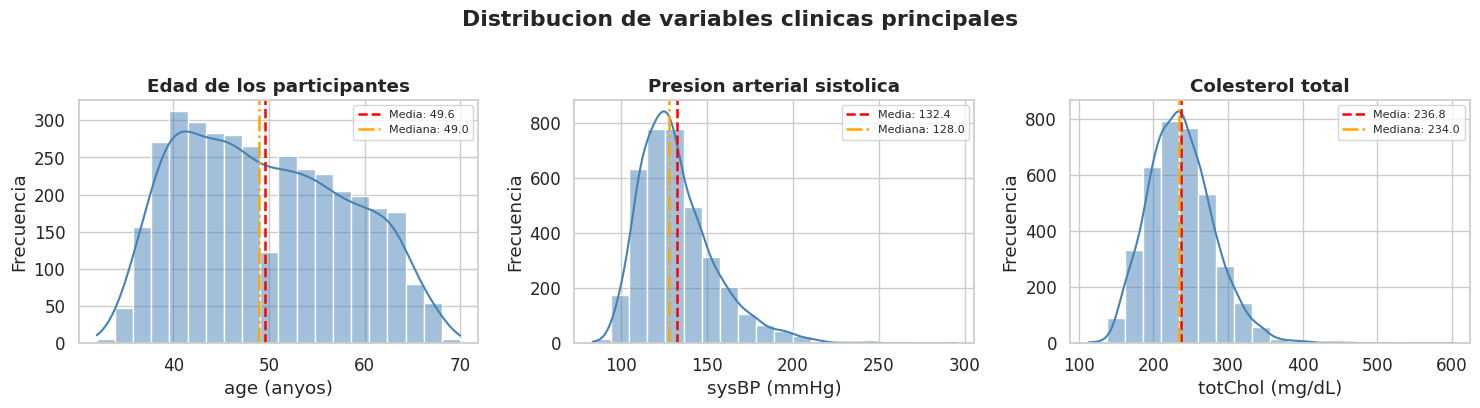

In [9]:
# Figura 1: Distribucion de variables continuas clave
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, titulo, unidad) in zip(axes, [
    ('age',    'Edad de los participantes',        'anyos'),
    ('sysBP',  'Presion arterial sistolica',        'mmHg'),
    ('totChol','Colesterol total',                  'mg/dL')
]):
    data = df[col].dropna()
    sns.histplot(data, bins=20, kde=True, ax=ax, color='steelblue')
    ax.axvline(data.mean(), color='red', lw=1.8, ls='--',
               label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', lw=1.8, ls='-.',
               label=f'Mediana: {data.median():.1f}')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(f'{col} ({unidad})')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.suptitle('Distribucion de variables clinicas principales', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figs/sumativa1/fig1_histogramas.pdf', bbox_inches='tight')
plt.show()


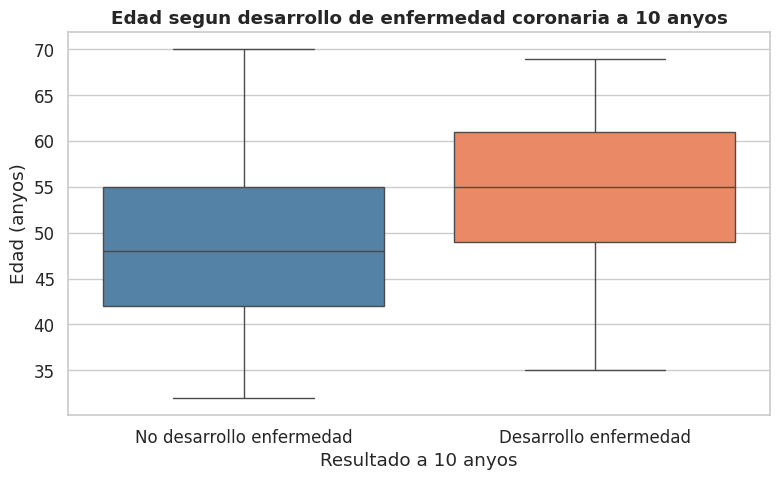

In [10]:
# Figura 2: Edad segun desarrollo de enfermedad coronaria (boxplot)
PALETTE_CHD = {
    'No desarrollo enfermedad': 'steelblue',
    'Desarrollo enfermedad':    'coral'
}

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='CHD_Label', y='age',
            hue='CHD_Label', palette=PALETTE_CHD, legend=False)
plt.title('Edad segun desarrollo de enfermedad coronaria a 10 anyos',
          fontweight='bold')
plt.xlabel('Resultado a 10 anyos')
plt.ylabel('Edad (anyos)')
plt.tight_layout()
plt.savefig('../figs/sumativa1/fig2_edad_chd.pdf', bbox_inches='tight')
plt.show()


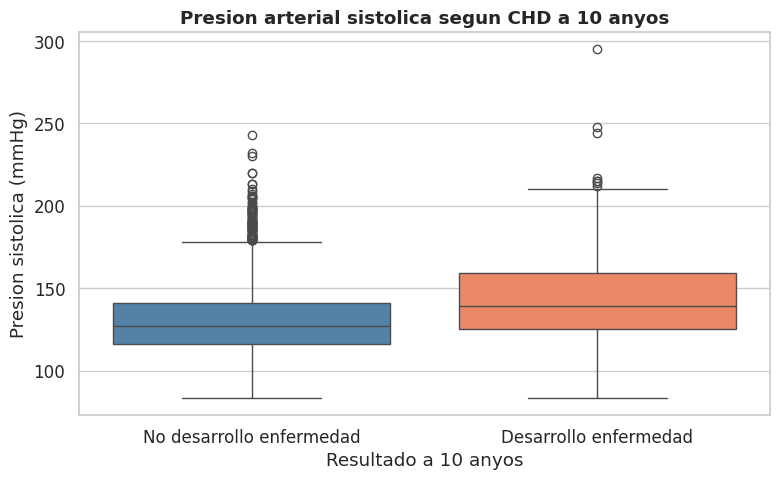

In [11]:
# Figura 3: Presion sistolica segun CHD (boxplot)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='CHD_Label', y='sysBP',
            hue='CHD_Label', palette=PALETTE_CHD, legend=False)
plt.title('Presion arterial sistolica segun CHD a 10 anyos', fontweight='bold')
plt.xlabel('Resultado a 10 anyos')
plt.ylabel('Presion sistolica (mmHg)')
plt.tight_layout()
plt.savefig('../figs/sumativa1/fig3_sysbp_chd.pdf', bbox_inches='tight')
plt.show()

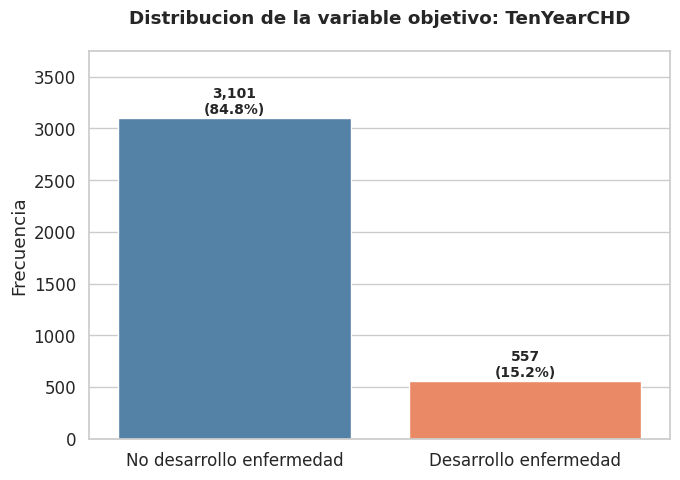

In [12]:
# Figura 4: Distribucion de la variable objetivo TenYearCHD
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x='CHD_Label',
              hue='CHD_Label', palette=PALETTE_CHD,
              legend=False, ax=ax)
for bar in ax.patches:
    n_bar = int(bar.get_height())
    pct   = n_bar / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            n_bar + 15,
            f'{n_bar:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_title('Distribucion de la variable objetivo: TenYearCHD',
             fontweight='bold', pad=20)
ax.set_xlabel('')
ax.set_ylabel('Frecuencia')
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.savefig('../figs/sumativa1/fig4_chd_dist.pdf', bbox_inches='tight')
plt.show()

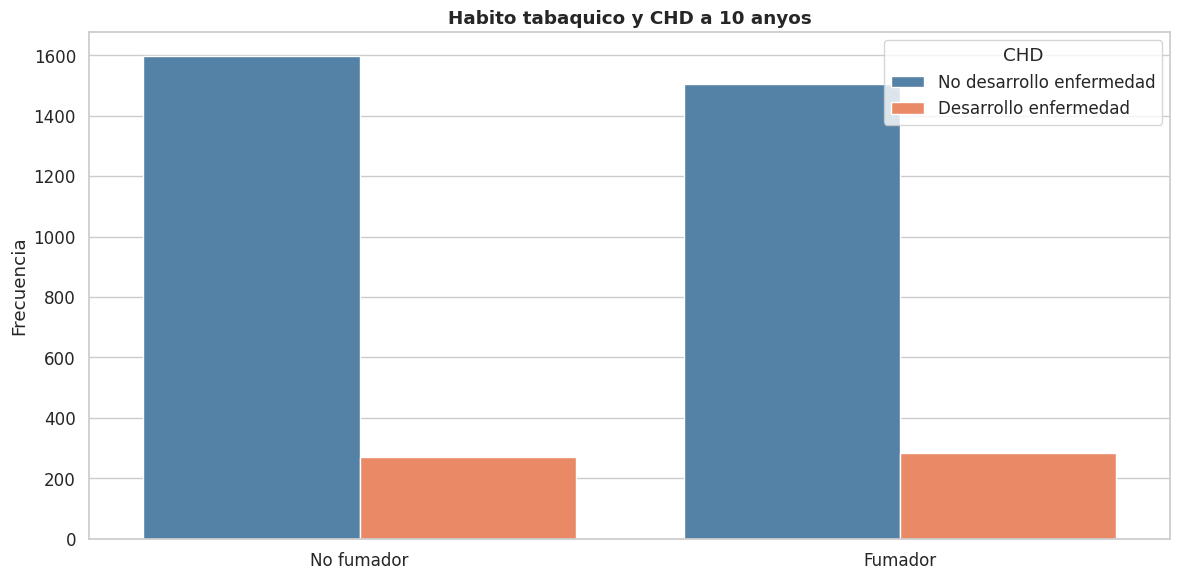

In [13]:
# Figura 5: Tabaquismo por resultado CHD (countplot)
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df, x='Smoker_Label', hue='CHD_Label',
                   palette=PALETTE_CHD)
plt.title('Habito tabaquico y CHD a 10 anyos', fontweight='bold')
plt.xlabel('')
plt.ylabel('Frecuencia')
plt.legend(title='CHD')
plt.tight_layout()
plt.savefig('../figs/sumativa1/fig5_smoker_chd.pdf', bbox_inches='tight')
plt.show()

---
## 5. Estimacion puntual e intervalos de confianza

Se calculan estimaciones puntuales e intervalos de confianza al 95% para cuatro parametros poblacionales. Se usa distribucion **t de Student** para medias (sigma desconocida) y metodo de **Wilson** para la proporcion de CHD.

La interpretacion correcta del IC es sobre el **procedimiento**: si repitiéramos el muestreo muchas veces, el 95% de los intervalos construidos contendrian el verdadero parametro poblacional.


In [14]:
# IC 95% para medias de variables clinicas (distribucion t)
# Justificacion: sigma poblacional desconocida -> se usa t de Student
# Con n=3.658 >> 30, el TLC garantiza normalidad de x_bar

n = len(df)

print('=== INTERVALOS DE CONFIANZA AL 95% PARA MEDIAS (distribucion t) ===')
print()

variables_ic = [
    ('age',    'Edad',               'anyos',  'Adultez media (OMS, 2021)'),
    ('totChol','Colesterol total',    'mg/dL',  'Rango limitrofe-alto (NCEP, 2002): >200 mg/dL'),
    ('sysBP',  'Presion sistolica',   'mmHg',   'Hipertension etapa 1 (AHA/ACC, 2018): >130 mmHg'),
]

resultados_ic = {}

for col, label, unidad, referencia in variables_ic:
    media = df[col].mean()
    std   = df[col].std(ddof=1)            # ddof=1: estimador muestral (Bessel)
    se    = std / np.sqrt(n)               # error estandar
    ic    = stats.t.interval(0.95, df=n-1, loc=media, scale=se)
    resultados_ic[col] = ic
    

    print(f'{label}:')
    print(f'  Estimacion puntual : x_bar = {media:.2f} {unidad}')
    print(f'  Error estandar     : SE = {se:.4f}')
    print(f'  IC 95%             : [{ic[0]:.2f} , {ic[1]:.2f}] {unidad}')
    print(f'  Referencia clinica : {referencia}')
    print(f'  Interpretacion     : Con 95% de confianza, el procedimiento de')
    print(f'    construccion del intervalo produce rangos que contienen la')
    print(f'    verdadera media poblacional. El IC [{ic[0]:.2f}, {ic[1]:.2f}] {unidad}')
    print(f'    indica que la media poblacional se ubica en ese rango.')    
    print()

=== INTERVALOS DE CONFIANZA AL 95% PARA MEDIAS (distribucion t) ===

Edad:
  Estimacion puntual : x_bar = 49.55 anyos
  Error estandar     : SE = 0.1416
  IC 95%             : [49.27 , 49.83] anyos
  Referencia clinica : Adultez media (OMS, 2021)
  Interpretacion     : Con 95% de confianza, el procedimiento de
    construccion del intervalo produce rangos que contienen la
    verdadera media poblacional. El IC [49.27, 49.83] anyos
    indica que la media poblacional se ubica en ese rango.

Colesterol total:
  Estimacion puntual : x_bar = 236.85 mg/dL
  Error estandar     : SE = 0.7291
  IC 95%             : [235.42 , 238.28] mg/dL
  Referencia clinica : Rango limitrofe-alto (NCEP, 2002): >200 mg/dL
  Interpretacion     : Con 95% de confianza, el procedimiento de
    construccion del intervalo produce rangos que contienen la
    verdadera media poblacional. El IC [235.42, 238.28] mg/dL
    indica que la media poblacional se ubica en ese rango.

Presion sistolica:
  Estimacion puntual : 

In [15]:
# IC 95% para la proporcion de TenYearCHD usando metodo de Wilson
# Justificacion: Wilson es mas preciso que Wald para proporciones,
# especialmente cuando p se aleja de 0.5 (caso con p=15.2%).

casos = int(df['TenYearCHD'].sum())
total = len(df)
p_hat = casos / total

ic_wilson = proportion_confint(casos, total, alpha=0.05, method='wilson')

print('=== IC 95% PARA PROPORCION DE CHD (metodo de Wilson) ===')
print()
print(f'  Estimacion puntual : p_hat = {p_hat:.4f} ({p_hat*100:.2f}%)')
print(f'  Casos positivos    : {casos:,} de {total:,} pacientes')
print(f'  IC 95% (Wilson)    : [{ic_wilson[0]:.4f} , {ic_wilson[1]:.4f}]')
print(f'                       [{ic_wilson[0]*100:.2f}% , {ic_wilson[1]*100:.2f}%]')
print()
print('  Por que Wilson y no Wald?')
print('  El metodo de Wald asume simetria alrededor de p_hat, lo que')
print('  introduce sesgo cuando p < 0.20. Wilson ajusta este sesgo')
print('  produciendo intervalos mas precisos y centrados.')
print()
print('  Interpretacion:')
print(f'  Con 95% de confianza (procedimiento), la proporcion poblacional')
print(f'  real de pacientes que desarrollan CHD a 10 anyos se ubica')
print(f'  entre el {ic_wilson[0]*100:.2f}% y el {ic_wilson[1]*100:.2f}%.')



=== IC 95% PARA PROPORCION DE CHD (metodo de Wilson) ===

  Estimacion puntual : p_hat = 0.1523 (15.23%)
  Casos positivos    : 557 de 3,658 pacientes
  IC 95% (Wilson)    : [0.1410 , 0.1643]
                       [14.10% , 16.43%]

  Por que Wilson y no Wald?
  El metodo de Wald asume simetria alrededor de p_hat, lo que
  introduce sesgo cuando p < 0.20. Wilson ajusta este sesgo
  produciendo intervalos mas precisos y centrados.

  Interpretacion:
  Con 95% de confianza (procedimiento), la proporcion poblacional
  real de pacientes que desarrollan CHD a 10 anyos se ubica
  entre el 14.10% y el 16.43%.


---
## 6. Pruebas de hipotesis

Se realizan **tres pruebas** seleccionadas segun el tipo de variable y la pregunta de investigacion. Nivel de significancia global: **alpha = 0.05**.

| Prueba | Tipo | Variables | Pregunta |
|---|---|---|---|
| 1 | t de Welch (dos muestras) | age / male | ¿Difiere la edad promedio entre hombres y mujeres? |
| 2 | Chi-cuadrado de independencia | currentSmoker / TenYearCHD | ¿Hay asociacion entre tabaquismo y CHD? |
| 3 | t de Welch (dos muestras) | glucose / diabetes | ¿Difiere la glucosa entre diabeticos y no diabeticos? |


In [16]:
# ================================================================
# PRUEBA 1: t de Welch - Edad promedio segun sexo
# Pregunta: ¿Existen diferencias significativas en la edad promedio
# entre hombres y mujeres en esta cohorte?
# ================================================================

# Segmentacion de grupos
edad_hombres = df[df['male'] == 1]['age']
edad_mujeres = df[df['male'] == 0]['age']

# Verificacion de supuestos
# n_hombres y n_mujeres >> 30 -> TLC garantiza normalidad de las medias muestrales
# Se usa equal_var=False (prueba de Welch) porque no se asume igualdad de varianzas
t_stat1, p_val1 = ttest_ind(edad_hombres, edad_mujeres, equal_var=False)

print('PRUEBA 1: t de Welch - Edad promedio segun sexo')
print('=' * 55)
print('  H0: mu_edad_hombres = mu_edad_mujeres')
print('  H1: mu_edad_hombres != mu_edad_mujeres')
print(f'  Tipo: bilateral | alpha = {ALPHA}')
print()
print(f'  Supuestos:')
print(f'    - Hombres: n = {len(edad_hombres):,} >> 30 -> TLC aplicable')
print(f'    - Mujeres: n = {len(edad_mujeres):,} >> 30 -> TLC aplicable')
print(f'    - Varianzas no asumidas iguales -> prueba de Welch')
print()
print(f'  Media edad hombres : {edad_hombres.mean():.2f} anyos')
print(f'  Media edad mujeres : {edad_mujeres.mean():.2f} anyos')
print(f'  Diferencia         : {abs(edad_hombres.mean()-edad_mujeres.mean()):.2f} anyos')
print(f'  Estadistico t      : {t_stat1:.4f}')
print(f'  p-valor            : {p_val1:.4f}')
print()
decision1 = 'SE RECHAZA H0' if p_val1 < ALPHA else 'NO SE RECHAZA H0'
print(f'  DECISION: p = {p_val1:.4f} {"<" if p_val1 < ALPHA else ">="} alpha = {ALPHA}'
      f' -> {decision1}')
print()
print('  CONCLUSION: No existe evidencia estadisticamente significativa')
print(f'  de diferencia en la edad promedio entre hombres ({edad_hombres.mean():.2f} anyos)')
print(f'  y mujeres ({edad_mujeres.mean():.2f} anyos) en esta cohorte (p = {p_val1:.4f}).')
print('  Las bases etarias de ambos subgrupos son homogeneas, por lo que')
print('  la edad no actua como variable confusora en el analisis por sexo.')


PRUEBA 1: t de Welch - Edad promedio segun sexo
  H0: mu_edad_hombres = mu_edad_mujeres
  H1: mu_edad_hombres != mu_edad_mujeres
  Tipo: bilateral | alpha = 0.05

  Supuestos:
    - Hombres: n = 1,623 >> 30 -> TLC aplicable
    - Mujeres: n = 2,035 >> 30 -> TLC aplicable
    - Varianzas no asumidas iguales -> prueba de Welch

  Media edad hombres : 49.32 anyos
  Media edad mujeres : 49.74 anyos
  Diferencia         : 0.42 anyos
  Estadistico t      : -1.4771
  p-valor            : 0.1397

  DECISION: p = 0.1397 >= alpha = 0.05 -> NO SE RECHAZA H0

  CONCLUSION: No existe evidencia estadisticamente significativa
  de diferencia en la edad promedio entre hombres (49.32 anyos)
  y mujeres (49.74 anyos) en esta cohorte (p = 0.1397).
  Las bases etarias de ambos subgrupos son homogeneas, por lo que
  la edad no actua como variable confusora en el analisis por sexo.


In [17]:
# ================================================================
# PRUEBA 2: Chi-cuadrado de independencia
# Pregunta: Existe asociacion entre el habito tabaquico actual
# (currentSmoker) y el desarrollo de CHD a 10 anyos (TenYearCHD)?
# ================================================================

# Construccion de tabla de contingencia
tabla_ct = pd.crosstab(
    df['currentSmoker'],
    df['TenYearCHD'],
    rownames=['Fumador'],
    colnames=['CHD']
)

# Ejecucion de la prueba
chi2_stat, p_val2, dof2, expected = chi2_contingency(tabla_ct)

# Verificacion criterio de Cochran: todas las frecuencias esperadas >= 5
cochran_ok = (expected >= 5).all()

print('PRUEBA 2: Chi-cuadrado de independencia')
print('=' * 55)
print('  H0: El habito tabaquico y el CHD son independientes')
print('  H1: Existe asociacion entre tabaquismo y CHD')
print(f'  Tipo: bilateral | alpha = {ALPHA}')
print()
print('  Tabla de contingencia:')
print(tabla_ct.rename(index={0:'No fumador',1:'Fumador'},
                      columns={0:'Sin CHD',1:'Con CHD'}))
print()
print(f'  Supuestos:')
print(f'    - Criterio de Cochran (frec. esperadas >= 5): {"OK" if cochran_ok else "NO CUMPLE"}')
print(f'    - Frecuencia esperada minima: {expected.min():.1f}')
print()
print(f'  Estadistico chi2   : {chi2_stat:.4f}')
print(f'  Grados de libertad : {dof2}')
print(f'  p-valor            : {p_val2:.4f}')
print()
decision2 = 'SE RECHAZA H0' if p_val2 < ALPHA else 'NO SE RECHAZA H0'
print(f'  DECISION: p = {p_val2:.4f} {"<" if p_val2 < ALPHA else ">="} alpha = {ALPHA}'
      f' -> {decision2}')
print()
print('  CONCLUSION: No existe evidencia estadisticamente significativa')
print('  de asociacion entre el tabaquismo actual y el CHD a 10 anyos')
print(f'  (chi2 = {chi2_stat:.4f}, p = {p_val2:.4f}).')
print('  Esto refleja la naturaleza multifactorial del riesgo cardiovascular:')
print('  el impacto del tabaco se potencia al interactuar con otros factores')
print('  (colesterol, hipertension) que un analisis bivariado aislado no captura.')


PRUEBA 2: Chi-cuadrado de independencia
  H0: El habito tabaquico y el CHD son independientes
  H1: Existe asociacion entre tabaquismo y CHD
  Tipo: bilateral | alpha = 0.05

  Tabla de contingencia:
CHD         Sin CHD  Con CHD
Fumador                     
No fumador     1597      272
Fumador        1504      285

  Supuestos:
    - Criterio de Cochran (frec. esperadas >= 5): OK
    - Frecuencia esperada minima: 272.4

  Estadistico chi2   : 1.2390
  Grados de libertad : 1
  p-valor            : 0.2657

  DECISION: p = 0.2657 >= alpha = 0.05 -> NO SE RECHAZA H0

  CONCLUSION: No existe evidencia estadisticamente significativa
  de asociacion entre el tabaquismo actual y el CHD a 10 anyos
  (chi2 = 1.2390, p = 0.2657).
  Esto refleja la naturaleza multifactorial del riesgo cardiovascular:
  el impacto del tabaco se potencia al interactuar con otros factores
  (colesterol, hipertension) que un analisis bivariado aislado no captura.


In [18]:
# ================================================================
# PRUEBA 3: t de Welch - Glucosa segun estado diabetico
# Pregunta: Existe diferencia significativa en los niveles medios
# de glucosa entre pacientes diabeticos y no diabeticos?
# Variable continua vs categorica binaria -> prueba t de dos muestras
# ================================================================

# Segmentacion de grupos
glucosa_diab    = df[df['diabetes'] == 1]['glucose']
glucosa_no_diab = df[df['diabetes'] == 0]['glucose']

# Prueba de Welch: no asume igualdad de varianzas
# Justificacion: pacientes diabeticos tienen mayor variabilidad
# en glucosa por diferencias en tratamiento y severidad
t_stat3, p_val3 = ttest_ind(glucosa_diab, glucosa_no_diab, equal_var=False)

print('PRUEBA 3: t de Welch - Glucosa segun estado diabetico')
print('=' * 55)
print('  H0: mu_glucosa_diabeticos = mu_glucosa_no_diabeticos')
print('  H1: mu_glucosa_diabeticos != mu_glucosa_no_diabeticos')
print(f'  Tipo: bilateral | alpha = {ALPHA}')
print()
print('  Supuestos:')
print(f'    - Diabeticos   : n = {len(glucosa_diab):,} >> 30 -> TLC aplicable')
print(f'    - No diabeticos: n = {len(glucosa_no_diab):,} >> 30 -> TLC aplicable')
print(f'    - Varianzas no asumidas iguales -> prueba de Welch')
print(f'    - Varianza diabeticos   : {glucosa_diab.std(ddof=1):.2f}')
print(f'    - Varianza no diabeticos: {glucosa_no_diab.std(ddof=1):.2f}')
print()
print(f'  Media glucosa diabeticos    : {glucosa_diab.mean():.2f} mg/dL')
print(f'  Media glucosa no diabeticos : {glucosa_no_diab.mean():.2f} mg/dL')
print(f'  Diferencia                  : {glucosa_diab.mean()-glucosa_no_diab.mean():.2f} mg/dL')
print(f'  Estadistico t (Welch)       : {t_stat3:.4f}')
print(f'  p-valor                     : {p_val3:.2e}')
print()
decision3 = 'SE RECHAZA H0' if p_val3 < ALPHA else 'NO SE RECHAZA H0'
print(f'  DECISION: p = {p_val3:.2e} {"<" if p_val3 < ALPHA else ">="} alpha = {ALPHA}'
      f' -> {decision3}')
print()
print('  CONCLUSION: Existe diferencia estadisticamente significativa')
print(f'  en los niveles de glucosa entre pacientes diabeticos')
print(f'  ({glucosa_diab.mean():.2f} mg/dL) y no diabeticos ({glucosa_no_diab.mean():.2f} mg/dL),')
print(f'  con una diferencia de {glucosa_diab.mean()-glucosa_no_diab.mean():.2f} mg/dL (p < 0.001).')
print('  Este resultado valida la consistencia del dataset y confirma que')
print('  la variable diabetes es un marcador efectivo del estado glucemico.')
print('  La diferencia es clinicamente relevante dado el umbral diagnostico')
print('  de diabetes: >= 126 mg/dL en ayuno (ADA, 2024).')


PRUEBA 3: t de Welch - Glucosa segun estado diabetico
  H0: mu_glucosa_diabeticos = mu_glucosa_no_diabeticos
  H1: mu_glucosa_diabeticos != mu_glucosa_no_diabeticos
  Tipo: bilateral | alpha = 0.05

  Supuestos:
    - Diabeticos   : n = 99 >> 30 -> TLC aplicable
    - No diabeticos: n = 3,559 >> 30 -> TLC aplicable
    - Varianzas no asumidas iguales -> prueba de Welch
    - Varianza diabeticos   : 84.84
    - Varianza no diabeticos: 12.93

  Media glucosa diabeticos    : 169.96 mg/dL
  Media glucosa no diabeticos : 79.40 mg/dL
  Diferencia                  : 90.56 mg/dL
  Estadistico t (Welch)       : 10.6173
  p-valor                     : 5.48e-18

  DECISION: p = 5.48e-18 < alpha = 0.05 -> SE RECHAZA H0

  CONCLUSION: Existe diferencia estadisticamente significativa
  en los niveles de glucosa entre pacientes diabeticos
  (169.96 mg/dL) y no diabeticos (79.40 mg/dL),
  con una diferencia de 90.56 mg/dL (p < 0.001).
  Este resultado valida la consistencia del dataset y confirma que


In [19]:
# Resumen de las tres pruebas
print('=======================================================')
print('  RESUMEN DE PRUEBAS DE HIPOTESIS')
print('=======================================================')
print(f'  alpha global = {ALPHA}')
print()
print(f'  Prueba 1 | t Welch    | Edad por sexo')
print(f'    t = {t_stat1:.4f} | p = {p_val1:.4f} | {"RECHAZA H0" if p_val1 < ALPHA else "NO RECHAZA H0"}')
print()
print(f'  Prueba 2 | Chi2       | Tabaquismo vs CHD')
print(f'    chi2 = {chi2_stat:.4f} | p = {p_val2:.4f} | {"RECHAZA H0" if p_val2 < ALPHA else "NO RECHAZA H0"}')
print()
print(f'  Prueba 3 | t Welch    | Glucosa por diabetes')
print(f'    t = {t_stat3:.4f} | p = {p_val3:.2e} | {"RECHAZA H0" if p_val3 < ALPHA else "NO RECHAZA H0"}')
print('=======================================================')


  RESUMEN DE PRUEBAS DE HIPOTESIS
  alpha global = 0.05

  Prueba 1 | t Welch    | Edad por sexo
    t = -1.4771 | p = 0.1397 | NO RECHAZA H0

  Prueba 2 | Chi2       | Tabaquismo vs CHD
    chi2 = 1.2390 | p = 0.2657 | NO RECHAZA H0

  Prueba 3 | t Welch    | Glucosa por diabetes
    t = 10.6173 | p = 5.48e-18 | RECHAZA H0


---
## 7. Analisis de correlaciones

Matriz de correlacion entre variables cuantitativas con nombres en espanol para facilitar la lectura e interpretacion clinica.


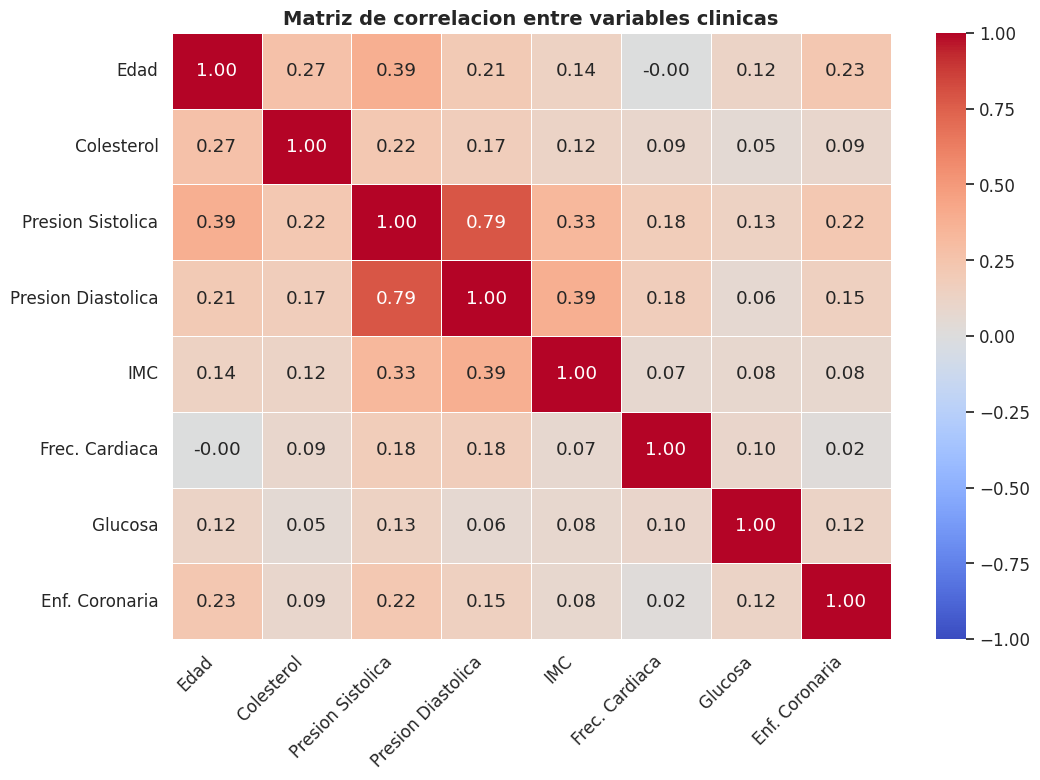

Correlacion de cada variable con Enf. Coronaria (de mayor a menor):
  Edad                     : r = 0.234
  Presion Sistolica        : r = 0.223
  Presion Diastolica       : r = 0.150
  Glucosa                  : r = 0.122
  Colesterol               : r = 0.091
  IMC                      : r = 0.082
  Frec. Cardiaca           : r = 0.021

Interpretacion fisiologica clave:
  - Presion Sistolica / Diastolica: r = 0.79 -> correlacion fuerte,
    consistente con la fisiologia cardiovascular (resistencia vascular).
  - Edad correlaciona positivamente con Presion Sistolica y Colesterol,
    reflejando la predisposicion al riesgo con el envejecimiento.


In [20]:
# Renombrar variables para la visualizacion
corr_df = df.rename(columns={
    'age':       'Edad',
    'totChol':   'Colesterol',
    'sysBP':     'Presion Sistolica',
    'diaBP':     'Presion Diastolica',
    'BMI':       'IMC',
    'heartRate': 'Frec. Cardiaca',
    'glucose':   'Glucosa',
    'TenYearCHD':'Enf. Coronaria'
})

CORR_VARS = ['Edad','Colesterol','Presion Sistolica','Presion Diastolica',
             'IMC','Frec. Cardiaca','Glucosa','Enf. Coronaria']

corr_matrix = corr_df[CORR_VARS].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5
)
plt.title('Matriz de correlacion entre variables clinicas',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../figs/sumativa1/fig6_correlaciones.pdf', bbox_inches='tight')
plt.show()

# Correlaciones con la variable objetivo
print('Correlacion de cada variable con Enf. Coronaria (de mayor a menor):')
top = corr_matrix['Enf. Coronaria'].drop('Enf. Coronaria').sort_values(ascending=False)
for var, val in top.items():
    print(f'  {var:25s}: r = {val:.3f}')

print()
print('Interpretacion fisiologica clave:')
print('  - Presion Sistolica / Diastolica: r = 0.79 -> correlacion fuerte,')
print('    consistente con la fisiologia cardiovascular (resistencia vascular).')
print('  - Edad correlaciona positivamente con Presion Sistolica y Colesterol,')
print('    reflejando la predisposicion al riesgo con el envejecimiento.')


---
## 8. Interpretacion y sintesis

Se sintetizan los hallazgos y se vinculan con el problema de **decision bajo incertidumbre**.


In [21]:
print('SINTESIS DE HALLAZGOS - FRAMINGHAM HEART STUDY')
print('=' * 60)
print()
print('DATASET:')
print(f'  {len(df_raw):,} registros originales | {len(df):,} registros validos (tras dropna)')
print(f'  16 variables | 9 cualitativas | 7 cuantitativas')
print()
print('ESTADISTICA DESCRIPTIVA (ID1.2):')
print(f'  Colesterol promedio : {df["totChol"].mean():.2f} mg/dL -> supera limite OMS (200)')
print(f'  IMC promedio        : {df["BMI"].mean():.2f} kg/m2 -> categoria sobrepeso')
print(f'  Presion sistolica   : {df["sysBP"].mean():.2f} mmHg -> hipertension etapa 1')
print(f'  CHD positivo        : {df["TenYearCHD"].mean()*100:.2f}% -> clases desbalanceadas')
print()
print('ESTIMACION PUNTUAL E IC (ID1.3):')
print('  Los IC al 95% para edad, colesterol y presion sistolica confirman')
print('  que los niveles poblacionales superan los umbrales clinicos de')
print('  referencia establecidos por la OMS, NCEP y AHA/ACC.')
print(f'  IC Wilson para CHD: [{ic_wilson[0]*100:.2f}%, {ic_wilson[1]*100:.2f}%]')
print()
print('PRUEBAS DE HIPOTESIS (ID1.4):')
print(f'  Prueba 1 (edad/sexo)      : p={p_val1:.4f} -> NO RECHAZA H0')
print( '    Las bases etarias por sexo son homogeneas en esta cohorte.')
print(f'  Prueba 2 (tabaquismo/CHD) : p={p_val2:.4f} -> NO RECHAZA H0')
print( '    El tabaquismo aislado no muestra asociacion bivariada con CHD.')
print(f'  Prueba 3 (glucosa/diab)   : p={p_val3:.2e} -> RECHAZA H0')
print( '    Diferencia de 90.6 mg/dL entre diabeticos y no diabeticos.')
print()
print('INTERPRETACION Y DECISION BAJO INCERTIDUMBRE:')
print('  El analisis bivariado muestra que variables individuales no bastan')
print('  para explicar el CHD: es un fenomeno multifactorial. Los ICs permiten')
print('  cuantificar la incertidumbre y orientar decisiones clinicas preventivas.')
print()
print('=' * 60)


SINTESIS DE HALLAZGOS - FRAMINGHAM HEART STUDY

DATASET:
  4,240 registros originales | 3,658 registros validos (tras dropna)
  16 variables | 9 cualitativas | 7 cuantitativas

ESTADISTICA DESCRIPTIVA (ID1.2):
  Colesterol promedio : 236.85 mg/dL -> supera limite OMS (200)
  IMC promedio        : 25.78 kg/m2 -> categoria sobrepeso
  Presion sistolica   : 132.37 mmHg -> hipertension etapa 1
  CHD positivo        : 15.23% -> clases desbalanceadas

ESTIMACION PUNTUAL E IC (ID1.3):
  Los IC al 95% para edad, colesterol y presion sistolica confirman
  que los niveles poblacionales superan los umbrales clinicos de
  referencia establecidos por la OMS, NCEP y AHA/ACC.
  IC Wilson para CHD: [14.10%, 16.43%]

PRUEBAS DE HIPOTESIS (ID1.4):
  Prueba 1 (edad/sexo)      : p=0.1397 -> NO RECHAZA H0
    Las bases etarias por sexo son homogeneas en esta cohorte.
  Prueba 2 (tabaquismo/CHD) : p=0.2657 -> NO RECHAZA H0
    El tabaquismo aislado no muestra asociacion bivariada con CHD.
  Prueba 3 (glucos